# Scaling Costs Dashboard
**Concept Link:** LLMs as giant matrices, parameter scaling

**Objective:** Translate scaling intuition (parameters, memory, latency) into measurable enterprise cost and ROI models. This notebook provides a safe, lightweight simulation suitable for class use. Enable optional micro-benchmarks if needed.

---
### What you will do
1) Define candidate model sizes and estimate memory and latency.
2) Visualize scaling curves.
3) Estimate energy and carbon for your expected usage.
4) Build an ROI view that balances quality vs. cost.


## 1. Setup
Install and import dependencies. For plots, we use matplotlib. Do not change styles or set colors.


In [2]:
# Imports
import math
import time
import statistics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt    #install matplotlib

pd.options.display.float_format = '{:,.4f}'.format

## 2. Define Model Candidates
You can edit the table below. `params_billion` is the parameter count in billions.
`bytes_per_param` depends on precision (e.g., 2 for 16-bit, 4 for 32-bit). `price_per_1k_tokens_usd` is an assumed cost for API usage.


In [3]:
models = pd.DataFrame([
    {"model": "Tiny-0.1B",   "params_billion": 0.1,  "bytes_per_param": 2, "price_per_1k_tokens_usd": 0.02},
    {"model": "Small-1B",    "params_billion": 1.0,  "bytes_per_param": 2, "price_per_1k_tokens_usd": 0.05},
    {"model": "Base-7B",     "params_billion": 7.0,  "bytes_per_param": 2, "price_per_1k_tokens_usd": 0.15},
    {"model": "Large-70B",   "params_billion": 70.0, "bytes_per_param": 2, "price_per_1k_tokens_usd": 0.90},
    {"model": "XL-175B",     "params_billion": 175.0,"bytes_per_param": 2, "price_per_1k_tokens_usd": 1.50}
])
models

,model,params_billion,bytes_per_param,price_per_1k_tokens_usd
0,Tiny-0.1B,0.1000,2,0.0200
1,Small-1B,1.0000,2,0.0500
2,Base-7B,7.0000,2,0.1500
3,Large-70B,70.0000,2,0.9000
4,XL-175B,175.0000,2,1.5000


## 3. Memory and Latency Estimates
We estimate memory as `params * bytes_per_param`. This is a lower bound for parameters only.
Latency is simulated with a simple scaling rule: `latency_ms ≈ base + k * params_billion^alpha`.
You can adjust the constants to match your environment.


In [4]:
# Adjustable constants
BASE_LATENCY_MS = 50.0      # baseline overhead per call
K_LATENCY = 8.0             # scale factor
ALPHA = 0.6                 # curvature for latency vs parameters

def estimate_memory_gb(params_billion, bytes_per_param=2):
    params = params_billion * 1e9
    mem_bytes = params * bytes_per_param
    return mem_bytes / (1024**3)

def estimate_latency_ms(params_billion, base_ms=BASE_LATENCY_MS, k=K_LATENCY, alpha=ALPHA):
    return base_ms + k * (params_billion ** alpha)

models = models.copy()
models["param_memory_gb"] = models.apply(lambda r: estimate_memory_gb(r.params_billion, r.bytes_per_param), axis=1)
models["est_latency_ms"] = models.apply(lambda r: estimate_latency_ms(r.params_billion), axis=1)
models

,model,params_billion,bytes_per_param,price_per_1k_tokens_usd,param_memory_gb,est_latency_ms
0,Tiny-0.1B,0.1000,2,0.0200,0.1863,52.0095
1,Small-1B,1.0000,2,0.0500,1.8626,58.0000
2,Base-7B,7.0000,2,0.1500,13.0385,75.7128
3,Large-70B,70.0000,2,0.9000,130.3852,152.3644
4,XL-175B,175.0000,2,1.5000,325.9629,227.3833


## 4. Plot Scaling Curves
We visualize memory and latency growth as a function of parameter count. Each chart is produced independently.


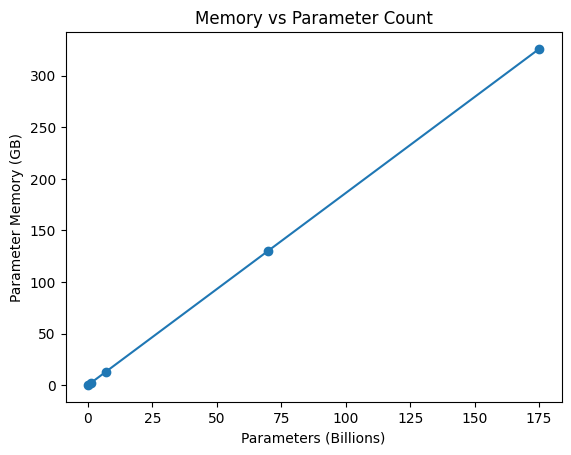

In [5]:
# Memory vs Parameters
plt.figure()
x = models["params_billion"].values
y = models["param_memory_gb"].values
plt.plot(x, y, marker='o')
plt.xlabel("Parameters (Billions)")
plt.ylabel("Parameter Memory (GB)")
plt.title("Memory vs Parameter Count")
plt.show()

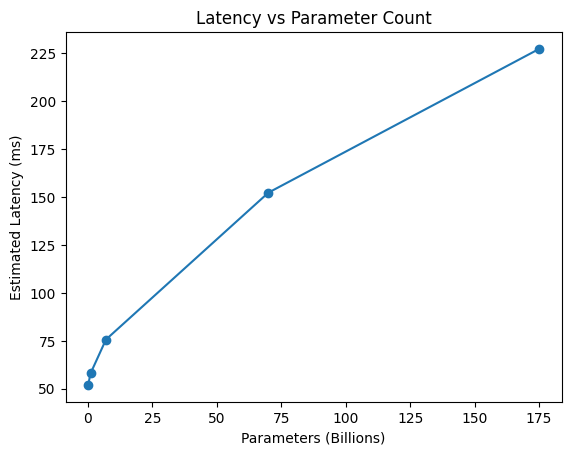

In [6]:
# Latency vs Parameters
plt.figure()
x = models["params_billion"].values
y = models["est_latency_ms"].values
plt.plot(x, y, marker='o')
plt.xlabel("Parameters (Billions)")
plt.ylabel("Estimated Latency (ms)")
plt.title("Latency vs Parameter Count")
plt.show()

## 5. Usage Scenario and Cost
Provide a usage scenario. The notebook estimates token usage costs using your assumed price per 1k tokens.


In [7]:
# Scenario assumptions (edit these)
TOKENS_PER_CALL = 800          # average tokens per request (prompt + completion)
CALLS_PER_DAY = 500            # average calls per day
DAYS_PER_MONTH = 22            # working days per month

def monthly_tokens(tokens_per_call=TOKENS_PER_CALL, calls_per_day=CALLS_PER_DAY, days_per_month=DAYS_PER_MONTH):
    return tokens_per_call * calls_per_day * days_per_month

def monthly_cost_usd(price_per_1k, tokens):
    return (tokens / 1000.0) * price_per_1k

tokens_m = monthly_tokens()
models["monthly_tokens"] = tokens_m
models["est_monthly_cost_usd"] = models.apply(lambda r: monthly_cost_usd(r.price_per_1k_tokens_usd, tokens_m), axis=1)
models[["model","params_billion","est_latency_ms","param_memory_gb","price_per_1k_tokens_usd","monthly_tokens","est_monthly_cost_usd"]]

,model,params_billion,est_latency_ms,param_memory_gb,price_per_1k_tokens_usd,monthly_tokens,est_monthly_cost_usd
0,Tiny-0.1B,0.1000,52.0095,0.1863,0.0200,8800000,176.0000
1,Small-1B,1.0000,58.0000,1.8626,0.0500,8800000,440.0000
2,Base-7B,7.0000,75.7128,13.0385,0.1500,8800000,"1,320.0000"
3,Large-70B,70.0000,152.3644,130.3852,0.9000,8800000,"7,920.0000"
4,XL-175B,175.0000,227.3833,325.9629,1.5000,8800000,"13,200.0000"


In [8]:
# --- Split input vs output token pricing (Usage Scenario and Cost) ---
PRICE_IN_PER_1K = 0.60   # $ per 1k input tokens (example)
PRICE_OUT_PER_1K = 1.80  # $ per 1k output tokens (example)
AVG_IN_TOKENS = 600
AVG_OUT_TOKENS = 200

def monthly_cost_split(price_in, price_out, in_tokens, out_tokens, calls_per_day=CALLS_PER_DAY, days_per_month=DAYS_PER_MONTH):
    t_in = in_tokens * calls_per_day * days_per_month
    t_out = out_tokens * calls_per_day * days_per_month
    return (t_in/1000.0)*price_in + (t_out/1000.0)*price_out, t_in + t_out

models = models.copy()
models["est_monthly_cost_usd"], models["monthly_tokens"] = monthly_cost_split(
    PRICE_IN_PER_1K, PRICE_OUT_PER_1K, AVG_IN_TOKENS, AVG_OUT_TOKENS
)


## 6. Energy and Carbon Estimate
This is a coarse classroom estimate. Adjust these parameters based on your environment and vendor disclosures.

- `joules_per_token` is a simplifying constant that scales with parameters.
- `PUE` is the data center Power Usage Effectiveness.
- `grid_kgco2_per_kwh` is the grid emissions factor.


In [9]:
# Adjustable environmental constants
BASE_JOULES_PER_TOKEN = 0.005   # baseline joules per token for a tiny model
BETA_ENERGY = 0.015             # additional joules per token scaling with params^beta
BETA = 0.5                      # curvature of energy vs params
PUE = 1.2                       # data center power usage effectiveness
GRID_KGCO2_PER_KWH = 0.7        # kg CO2 per kWh for your grid

def energy_joules_per_token(params_billion, base=BASE_JOULES_PER_TOKEN, beta=BETA_ENERGY, curvature=BETA):
    return base + beta * (params_billion ** curvature)

def monthly_energy_kwh(tokens, params_billion):
    jpt = energy_joules_per_token(params_billion)
    joules = tokens * jpt * PUE
    return joules / (3.6e6)

def monthly_co2_kg(kwh):
    return kwh * GRID_KGCO2_PER_KWH

models = models.copy()
models["energy_kwh_per_month"] = models.apply(lambda r: monthly_energy_kwh(tokens_m, r.params_billion), axis=1)
models["co2_kg_per_month"] = models.apply(lambda r: monthly_co2_kg(r.energy_kwh_per_month), axis=1)
models[["model","params_billion","energy_kwh_per_month","co2_kg_per_month","est_monthly_cost_usd"]]

,model,params_billion,energy_kwh_per_month,co2_kg_per_month,est_monthly_cost_usd
0,Tiny-0.1B,0.1000,0.0286,0.0200,"7,920.0000"
1,Small-1B,1.0000,0.0587,0.0411,"7,920.0000"
2,Base-7B,7.0000,0.1311,0.0918,"7,920.0000"
3,Large-70B,70.0000,0.3828,0.2680,"7,920.0000"
4,XL-175B,175.0000,0.5967,0.4177,"7,920.0000"


## 7. ROI Calculator
Define a simple benefit model: estimated business value per task, number of tasks per month, and a quality uplift factor by model size.
ROI is computed as `(Benefit - Cost) / Cost`.


In [10]:
# Edit assumptions
VALUE_PER_TASK_USD = 2.50          # monetary value per successful AI-supported task
TASKS_PER_MONTH = 8000              # tasks influenced by the model per month

# Assign a quality uplift factor by model size (1.0 means baseline quality)
uplift_map = {
    "Tiny-0.1B": 1.00,
    "Small-1B": 1.05,
    "Base-7B": 1.15,
    "Large-70B": 1.30,
    "XL-175B": 1.35,
}

models = models.copy()
models["quality_uplift"] = models["model"].map(uplift_map).fillna(1.0)
models["est_benefit_usd"] = VALUE_PER_TASK_USD * TASKS_PER_MONTH * models["quality_uplift"]
models["roi"] = (models["est_benefit_usd"] - models["est_monthly_cost_usd"]) / models["est_monthly_cost_usd"]
models.sort_values("roi", ascending=False)

,model,params_billion,bytes_per_param,price_per_1k_tokens_usd,param_memory_gb,est_latency_ms,monthly_tokens,est_monthly_cost_usd,energy_kwh_per_month,co2_kg_per_month,quality_uplift,est_benefit_usd,roi
4,XL-175B,175.0000,2,1.5000,325.9629,227.3833,8800000,"7,920.0000",0.5967,0.4177,1.3500,"27,000.0000",2.4091
3,Large-70B,70.0000,2,0.9000,130.3852,152.3644,8800000,"7,920.0000",0.3828,0.2680,1.3000,"26,000.0000",2.2828
2,Base-7B,7.0000,2,0.1500,13.0385,75.7128,8800000,"7,920.0000",0.1311,0.0918,1.1500,"23,000.0000",1.9040
1,Small-1B,1.0000,2,0.0500,1.8626,58.0000,8800000,"7,920.0000",0.0587,0.0411,1.0500,"21,000.0000",1.6515
0,Tiny-0.1B,0.1000,2,0.0200,0.1863,52.0095,8800000,"7,920.0000",0.0286,0.0200,1.0000,"20,000.0000",1.5253


## 8. Export Tables
Export the summary to CSV for reporting or to Excel using the provided template.


In [14]:
summary_cols = [
    "model","params_billion","param_memory_gb","est_latency_ms",
    "price_per_1k_tokens_usd","monthly_tokens","est_monthly_cost_usd",
    "energy_kwh_per_month","co2_kg_per_month","quality_uplift","est_benefit_usd","roi"
]
summary = models[summary_cols].copy()
summary_path_csv = r"C:\Users\SrikanthRachakulla\OneDrive - Protiviti Member Firm\Documents\ZS Associates_Aug_Training\labs\zs_ai_engineering\data\ScalingROI_summary.csv"
summary.to_csv(summary_path_csv, index=False)
summary_path_csv

'C:\\Users\\SrikanthRachakulla\\OneDrive - Protiviti Member Firm\\Documents\\ZS Associates_Aug_Training\\labs\\zs_ai_engineering\\data\\ScalingROI_summary.csv'

---
### Reflection Prompts
1) Which model offers the best ROI under your assumptions, and why?
2) How sensitive is your decision to token price or task value assumptions?
3) What governance would you apply before scaling up to a much larger model?

### Leadership Provocation
Should your AI roadmap target the largest available model, or a right-sized model per use case with clear ROI triggers?
